In [ ]:
import pandas as pd
import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,prepareTrainingSet30Sec,standardization,accuracy,metrics,Grafico_Before_After,Grafico_Tre_Valori # type: ignore
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt  
from sklearn.metrics import accuracy_score



In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()

senza nulla

In [3]:

model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
before_30sec=accuracy_score(y_test, y_pred)

Accuratezza: 0.7650
Precision: 0.7753
Recall: 0.7796
F1-score: 0.7734
F2-score: 0.7760


Applichiamo una standardizzazione

In [4]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0)
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
before_30sec_standadization=accuracy_score(y_test, y_pred)

Accuratezza: 0.7650
Precision: 0.7765
Recall: 0.7822
F1-score: 0.7748
F2-score: 0.7780


In [6]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [50, 100],  # Numero di alberi nella foresta
    'max_depth': [20, 30, 40],  # Profondità massima di ciascun albero
    'min_samples_split': [2, 5],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1, 2],    # Minimo numero di campioni richiesti in una foglia
    'bootstrap': [True, False]        # Uso del bootstrap per campionare i dati
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
metrics(y_test, y_pred)
after_30sec=accuracy_score(y_test, y_pred)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Migliori iperparametri trovati: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuratezza: 0.7750
Precision: 0.7768
Recall: 0.7904
F1-score: 0.7776
F2-score: 0.7839


<h2>Grafico confronto 30 sec

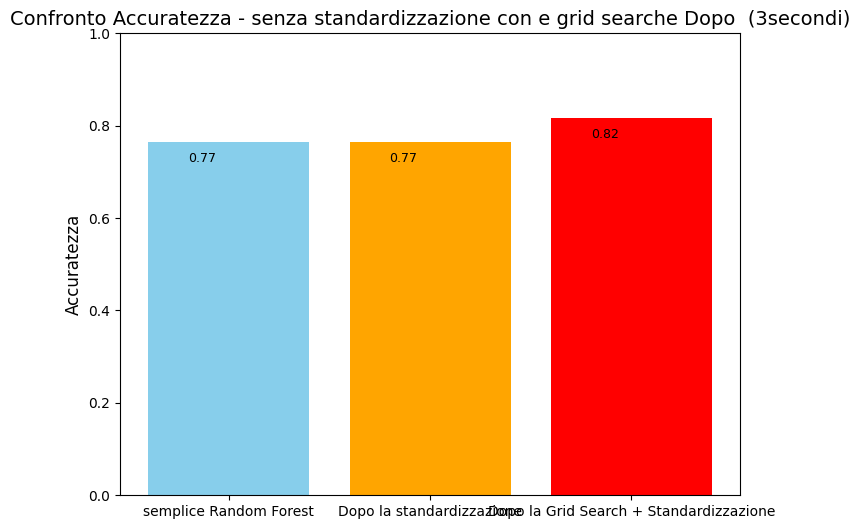

In [24]:
Grafico_Tre_Valori(before_30sec,before_30sec_standadization,after_30sec)

In [21]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

Eseguo il randomForest senza standardizazione

In [22]:
model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
before_3sec=accuracy_score(y_test, y_pred)

Accuratezza: 0.8178
Precision: 0.8174
Recall: 0.8177
F1-score: 0.8146
F2-score: 0.8159


Applichiamo la standardizzazione

In [10]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model=RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0)
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
before_30sec_standadization=accuracy_score(y_test, y_pred)


Accuratezza: 0.8168
Precision: 0.8163
Recall: 0.8167
F1-score: 0.8138
F2-score: 0.8150


Uso il gridSearch per ottimizzare i iperparametri e avere delle soluzione migliori

In [25]:
# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [50, 200 ,500],  # Numero di alberi nella foresta
    'max_depth': [20, 30, 40],  # Profondità massima di ciascun albero
    'min_samples_split': [2, 5],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1, 2],    # Minimo numero di campioni richiesti in una foglia
    'bootstrap': [True, False]        # Uso del bootstrap per campionare i dati
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
metrics(y_test, y_pred)
after_3sec=accuracy_score(y_test, y_pred)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [19]:
Grafico_Tre_Valori(before_3sec,before_3sec_standadization,after_3sec)

NameError: name 'before_3sec_standadization' is not defined

Voglio creare un grafico orizzontale con lasse delle x i 3 casi e 2 line una dei 30 e una dei 3 sec e vedere come cambiano 

Utilizzo il lasso per fare feature selection e abbassare la complessita computazionale 
(ho un risultato peggiore ma risparmio in memoria)

Accuratezza per ogni fold: [0.69, 0.73, 0.74, 0.7, 0.75, 0.75, 0.73, 0.78, 0.7, 0.72]
Accuratezza media dopo K-Fold: 0.7290

Feature selezionate dal Lasso: ['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc19_mean', 'mfcc20_mean', 'mfcc20_var']
Indice di feature selezionate: [ 0  1  2  3 

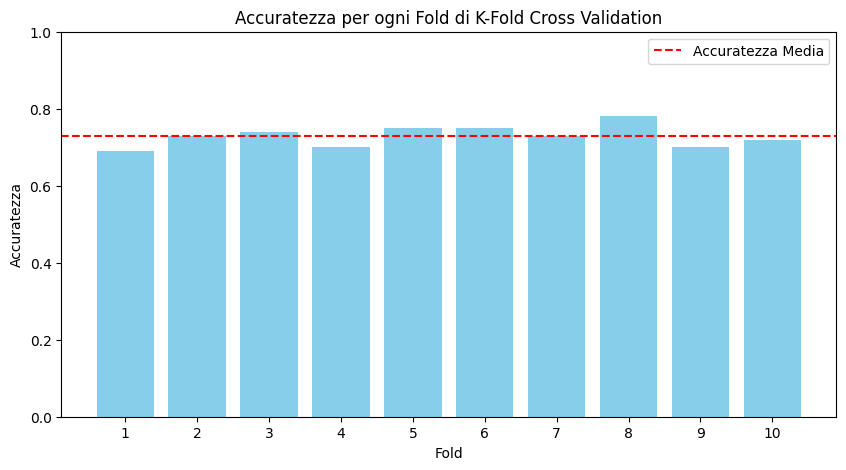

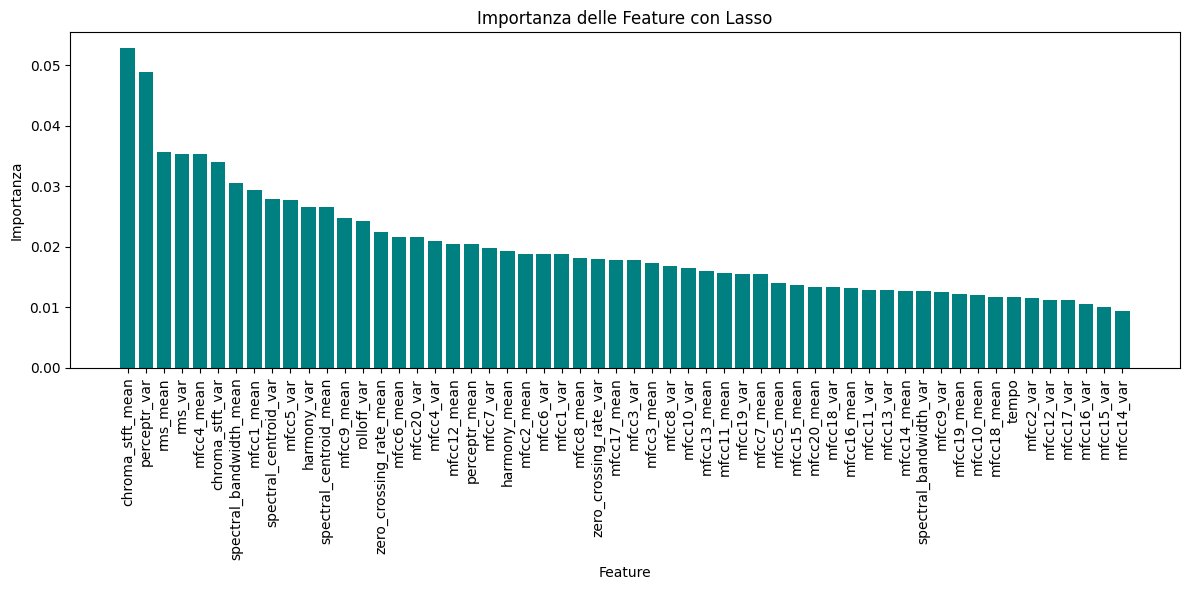

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label','length'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
importances_dict = {}  # Dizionario per tracciare le importanze delle feature selezionate

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Random Forest sulle feature selezionate
    model = RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100)
    model.fit(X_train_selected, y_train)

    # Calcolare l'importanza delle feature
    importances = model.feature_importances_
    
    # Salvare le importanze solo per le feature selezionate
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]  # Ottieni il nome della feature
        if feature_name in importances_dict:
            importances_dict[feature_name].append(importances[i])
        else:
            importances_dict[feature_name] = [importances[i]]

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print("Indice di feature selezionate:",(selected_features))
print("Numero di feature selezionate:", len(selected_feature_names))

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature con Lasso')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
